# CUDA-Based Parallel Processing for Diabetes Classification Using the K-Nearest Neighbor Algorithm

This notebook implements diabetes classification using the K-Nearest Neighbor (KNN) algorithm. The first implementation runs serially on the CPU as a baseline, while the second implementation uses CUDA to accelerate distance calculations on the GPU.

The comparison is performed based on execution time, speedup, accuracy, and confusion matrix.

## CUDA Environment Verification

CUDA requires an NVIDIA GPU and the NVCC compiler. In Google Colab, ensure that the GPU runtime is enabled before executing the following cell.

In [166]:
!nvidia-smi
!nvcc --version

Thu Jun 11 16:08:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Library Import and Directory Setup

This cell imports the required libraries and automatically creates the project directory structure.

In [167]:
import os
import time
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

for folder in [
    Path("data/raw"),
    Path("data/processed"),
    Path("outputs/results"),
    Path("outputs/figures"),
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Folder proyek siap digunakan.")

Folder proyek siap digunakan.


## Dataset Loading

The notebook first searches for the primary dataset file. If it is not found, alternative file names will be checked automatically.

In [168]:
primary_dataset = Path("data/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
alternative_dataset = Path("data/raw/diabetes_binary_health_indicators_BRFSS2015.csv")

if primary_dataset.exists():
    dataset_path = primary_dataset
elif alternative_dataset.exists():
    dataset_path = alternative_dataset
else:
    raise FileNotFoundError(
        "The dataset was not found. Please place the Diabetes Health Indicators CSV file inside data/raw/."
    )

df = pd.read_csv(dataset_path)
print(f"Dataset dimuat dari: {dataset_path}")
print(f"Ukuran dataset: {df.shape}")

Dataset dimuat dari: data/raw/diabetes_binary_5050split_health_indicators_BRFSS2015.csv
Ukuran dataset: (70692, 22)


## Dataset Preview

The dataset contains health indicators used to classify diabetes status through the `Diabetes_binary` target column.

In [169]:
display(df.head())
df.info()

print("Distribusi kelas Diabetes_binary:")
display(df["Diabetes_binary"].value_counts().sort_index())

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

,count
Diabetes_binary,
0.0,35346
1.0,35346


## Data Preprocessing

The dataset is separated into features and target variables, and the features are normalized using `StandardScaler`.

A full KNN implementation has a high computational cost because each testing sample must be compared with every training sample. For experimentation and debugging purposes, the number of samples can be limited using `MAX_TRAIN_SAMPLES` and `MAX_TEST_SAMPLES`.

In [170]:
TARGET_COLUMN = "Diabetes_binary"
MAX_TRAIN_SAMPLES = 100000
MAX_TEST_SAMPLES = 5000

if TARGET_COLUMN not in df.columns:
    raise ValueError(f"Kolom target {TARGET_COLUMN} tidak ditemukan di dataset.")

X = df.drop(columns=[TARGET_COLUMN]).values.astype(np.float32)
y = df[TARGET_COLUMN].values.astype(np.int32)

scaler = StandardScaler()
X = scaler.fit_transform(X).astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=81,
    stratify=y
)

if MAX_TRAIN_SAMPLES is not None and len(X_train) > MAX_TRAIN_SAMPLES:
    X_train = X_train[:MAX_TRAIN_SAMPLES]
    y_train = y_train[:MAX_TRAIN_SAMPLES]

if MAX_TEST_SAMPLES is not None and len(X_test) > MAX_TEST_SAMPLES:
    X_test = X_test[:MAX_TEST_SAMPLES]
    y_test = y_test[:MAX_TEST_SAMPLES]

pd.DataFrame(X_train).to_csv("data/processed/X_train.csv", index=False, header=False)
pd.DataFrame(X_test).to_csv("data/processed/X_test.csv", index=False, header=False)
pd.DataFrame(y_train).to_csv("data/processed/y_train.csv", index=False, header=False)
pd.DataFrame(y_test).to_csv("data/processed/y_test.csv", index=False, header=False)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (56553, 21)
X_test: (5000, 21)
y_train: (56553,)
y_test: (5000,)


## CPU Serial KNN

This implementation uses manual Python loops, Euclidean distance, and `k = 5` without relying on `KNeighborsClassifier`. The execution time is stored in the `cpu_time` variable.

In [171]:
def cpu_knn_predict(X_train, y_train, X_test, k=5):
    predictions = []
    for test_row in X_test:
        distances = np.sqrt(np.sum((X_train - test_row) ** 2, axis=1))
        nearest_indices = np.argsort(distances)[:k]
        nearest_labels = y_train[nearest_indices]
        counts = np.bincount(nearest_labels.astype(np.int32), minlength=2)
        predictions.append(np.argmax(counts))
    return np.array(predictions, dtype=np.int32)

k = 5
cpu_start = time.perf_counter()
y_pred_cpu = cpu_knn_predict(X_train, y_train, X_test, k=k)
cpu_time = time.perf_counter() - cpu_start

cpu_accuracy = accuracy_score(y_test, y_pred_cpu)
cpu_cm = confusion_matrix(y_test, y_pred_cpu)

print(f"CPU execution time: {cpu_time:.6f} seconds")
print(f"CPU accuracy: {cpu_accuracy:.6f}")
print("CPU confusion matrix:")
print(cpu_cm)

CPU execution time: 23.033822 seconds
CPU accuracy: 0.720000
CPU confusion matrix:
[[1739  781]
 [ 619 1861]]


## Writing CUDA Source Code

This cell generates the `knn_cuda.cu` file. The CUDA program reads the preprocessed data, computes distances in parallel on the GPU, performs KNN voting, and saves the prediction results.

In [ ]:
%%writefile knn_cuda.cu
#include <cuda_runtime.h>

#include <algorithm>
#include <chrono>
#include <cmath>
#include <fstream>
#include <iostream>
#include <sstream>
#include <stdexcept>
#include <string>
#include <vector>

#define CUDA_CHECK(call)                                                                  \
    do {                                                                                  \
        cudaError_t error = call;                                                         \
        if (error != cudaSuccess) {                                                       \
            std::cerr << "CUDA error at " << __FILE__ << ":" << __LINE__ << " -> "       \
                      << cudaGetErrorString(error) << std::endl;                          \
            std::exit(EXIT_FAILURE);                                                      \
        }                                                                                 \
    } while (0)

// Kernel CUDA: setiap thread ngitung satu jarak antara satu data uji
// dan satu data latih. Indeks global thread dibuat dari blockIdx, blockDim,
// dan threadIdx biar semua pasangan test-train bisa diproses paralel.
__global__ void computeDistancesKernel(
    const float* X_train,
    const float* X_test,
    float* distances,
    int n_train,
    int n_test,
    int n_features
) {
    int global_thread_id = blockIdx.x * blockDim.x + threadIdx.x;
    int total_pairs = n_train * n_test;

    if (global_thread_id >= total_pairs) {
        return;
    }

    int test_idx = global_thread_id / n_train;
    int train_idx = global_thread_id % n_train;

    float sum = 0.0f;
    for (int feature = 0; feature < n_features; feature++) {
        float diff = X_test[test_idx * n_features + feature] -
                     X_train[train_idx * n_features + feature];
        sum += diff * diff;
    }

    distances[test_idx * n_train + train_idx] = sqrtf(sum);
}

std::vector<std::vector<float>> readFeatureCSV(const std::string& path, int& rows, int& cols) {
    std::ifstream file(path);
    if (!file.is_open()) {
        throw std::runtime_error("Cannot open file: " + path);
    }

    std::vector<std::vector<float>> data;
    std::string line;

    while (std::getline(file, line)) {
        if (line.empty()) {
            continue;
        }

        std::stringstream ss(line);
        std::string value;
        std::vector<float> row;

        while (std::getline(ss, value, ',')) {
            row.push_back(std::stof(value));
        }

        if (!row.empty()) {
            data.push_back(row);
        }
    }

    rows = static_cast<int>(data.size());
    cols = rows > 0 ? static_cast<int>(data[0].size()) : 0;
    return data;
}

std::vector<int> readLabelCSV(const std::string& path) {
    std::ifstream file(path);
    if (!file.is_open()) {
        throw std::runtime_error("Cannot open file: " + path);
    }

    std::vector<int> labels;
    std::string line;

    while (std::getline(file, line)) {
        if (line.empty()) {
            continue;
        }
        labels.push_back(std::stoi(line));
    }

    return labels;
}

std::vector<float> flatten(const std::vector<std::vector<float>>& matrix) {
    std::vector<float> flat;
    if (matrix.empty()) {
        return flat;
    }

    flat.reserve(matrix.size() * matrix[0].size());
    for (const auto& row : matrix) {
        for (float value : row) {
            flat.push_back(value);
        }
    }
    return flat;
}

int voteKNearest(const float* distances, const std::vector<int>& y_train, int n_train, int test_idx, int k) {
    std::vector<std::pair<float, int>> dist_label;
    dist_label.reserve(n_train);

    for (int train_idx = 0; train_idx < n_train; train_idx++) {
        float distance = distances[test_idx * n_train + train_idx];
        dist_label.push_back({distance, y_train[train_idx]});
    }

    std::partial_sort(
        dist_label.begin(),
        dist_label.begin() + k,
        dist_label.end(),
        [](const auto& a, const auto& b) {
            return a.first < b.first;
        }
    );

    int count_0 = 0;
    int count_1 = 0;
    for (int i = 0; i < k; i++) {
        if (dist_label[i].second == 1) {
            count_1++;
        } else {
            count_0++;
        }
    }

    return count_1 >= count_0 ? 1 : 0;
}

void writePredictions(const std::string& path, const std::vector<int>& predictions) {
    std::ofstream file(path);
    if (!file.is_open()) {
        throw std::runtime_error("Cannot write file: " + path);
    }

    file << "prediction\n";
    for (int prediction : predictions) {
        file << prediction << "\n";
    }
}

int main() {
    const std::string x_train_path = "data/processed/X_train.csv";
    const std::string x_test_path = "data/processed/X_test.csv";
    const std::string y_train_path = "data/processed/y_train.csv";
    const std::string y_test_path = "data/processed/y_test.csv";
    const std::string output_path = "outputs/results/gpu_predictions.csv";
    const int k = 5;

    auto total_start = std::chrono::high_resolution_clock::now();

    int n_train = 0;
    int n_features_train = 0;
    int n_test = 0;
    int n_features_test = 0;

    std::vector<std::vector<float>> X_train_matrix = readFeatureCSV(x_train_path, n_train, n_features_train);
    std::vector<std::vector<float>> X_test_matrix = readFeatureCSV(x_test_path, n_test, n_features_test);
    std::vector<int> y_train = readLabelCSV(y_train_path);
    std::vector<int> y_test = readLabelCSV(y_test_path);

    if (n_train == 0 || n_test == 0) {
        throw std::runtime_error("Training or testing data is empty.");
    }

    if (n_features_train != n_features_test) {
        throw std::runtime_error("Feature count mismatch between train and test data.");
    }

    if (static_cast<int>(y_train.size()) != n_train) {
        throw std::runtime_error("y_train length does not match X_train rows.");
    }

    if (static_cast<int>(y_test.size()) != n_test) {
        throw std::runtime_error("y_test length does not match X_test rows.");
    }

    if (n_train < k) {
        throw std::runtime_error("Training samples must be at least k.");
    }

    int n_features = n_features_train;
    std::vector<float> X_train = flatten(X_train_matrix);
    std::vector<float> X_test = flatten(X_test_matrix);
    std::vector<float> distances(static_cast<size_t>(n_train) * n_test);

    float* d_X_train = nullptr;
    float* d_X_test = nullptr;
    float* d_distances = nullptr;

    size_t train_bytes = X_train.size() * sizeof(float);
    size_t test_bytes = X_test.size() * sizeof(float);
    size_t distance_bytes = distances.size() * sizeof(float);

    CUDA_CHECK(cudaMalloc(&d_X_train, train_bytes));
    CUDA_CHECK(cudaMalloc(&d_X_test, test_bytes));
    CUDA_CHECK(cudaMalloc(&d_distances, distance_bytes));

    CUDA_CHECK(cudaMemcpy(d_X_train, X_train.data(), train_bytes, cudaMemcpyHostToDevice));
    CUDA_CHECK(cudaMemcpy(d_X_test, X_test.data(), test_bytes, cudaMemcpyHostToDevice));

    int block_size = 256;
    int total_pairs = n_train * n_test;
    int grid_size = (total_pairs + block_size - 1) / block_size;
    int total_launched_threads = grid_size * block_size;

    cudaEvent_t kernel_start;
    cudaEvent_t kernel_stop;
    CUDA_CHECK(cudaEventCreate(&kernel_start));
    CUDA_CHECK(cudaEventCreate(&kernel_stop));

    CUDA_CHECK(cudaEventRecord(kernel_start));
    computeDistancesKernel<<<grid_size, block_size>>>(
        d_X_train,
        d_X_test,
        d_distances,
        n_train,
        n_test,
        n_features
    );
    CUDA_CHECK(cudaGetLastError());
    CUDA_CHECK(cudaEventRecord(kernel_stop));
    CUDA_CHECK(cudaEventSynchronize(kernel_stop));

    float kernel_time_ms = 0.0f;
    CUDA_CHECK(cudaEventElapsedTime(&kernel_time_ms, kernel_start, kernel_stop));

    CUDA_CHECK(cudaMemcpy(distances.data(), d_distances, distance_bytes, cudaMemcpyDeviceToHost));

    std::vector<int> predictions;
    predictions.reserve(n_test);
    for (int test_idx = 0; test_idx < n_test; test_idx++) {
        predictions.push_back(voteKNearest(distances.data(), y_train, n_train, test_idx, k));
    }

    writePredictions(output_path, predictions);

    CUDA_CHECK(cudaFree(d_X_train));
    CUDA_CHECK(cudaFree(d_X_test));
    CUDA_CHECK(cudaFree(d_distances));
    CUDA_CHECK(cudaEventDestroy(kernel_start));
    CUDA_CHECK(cudaEventDestroy(kernel_stop));

    auto total_stop = std::chrono::high_resolution_clock::now();
    std::chrono::duration<double> total_elapsed = total_stop - total_start;

    std::cout << "GPU kernel time (seconds): " << kernel_time_ms / 1000.0f << std::endl;
    std::cout << "GPU total time (seconds): " << total_elapsed.count() << std::endl;
    std::cout << "Training samples: " << n_train << std::endl;
    std::cout << "Testing samples: " << n_test << std::endl;
    std::cout << "Features: " << n_features << std::endl;
    std::cout << "Block size: " << block_size << std::endl;
    std::cout << "Grid size: " << grid_size << std::endl;
    std::cout << "Total launched threads: " << total_launched_threads << std::endl;
    std::cout << "Predictions saved to: " << output_path << std::endl;

    return 0;
}

Overwriting knn_cuda.cu


## CUDA Compilation

This cell compiles the CUDA program using the NVCC compiler.

In [173]:
!nvcc -O3 knn_cuda.cu -o knn_cuda

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


## Running the CUDA Program

The CUDA program generates the file `outputs/results/gpu_predictions.csv`, which contains the prediction results produced by the GPU implementation.

In [174]:
!./knn_cuda

GPU kernel time (seconds): 0.0905663
GPU total time (seconds): 3.3704
Training samples: 56553
Testing samples: 5000
Features: 21
Block size: 256
Grid size: 1104551
Total launched threads: 282765056
Predictions saved to: outputs/results/gpu_predictions.csv


## Evaluation Results Table

This table summarizes the accuracy, execution time, and speedup of both implementations. If the GPU execution time is not yet available as a Python variable, rerun the CUDA program through `subprocess` to capture the timing information.

In [175]:
gpu_pred_path = Path("outputs/results/gpu_predictions.csv")
if not gpu_pred_path.exists():
    raise FileNotFoundError("File prediksi GPU tidak ditemukan. Jalankan program CUDA terlebih dahulu.")

gpu_predictions = pd.read_csv(gpu_pred_path)["prediction"].values.astype(np.int32)

gpu_accuracy = accuracy_score(y_test, gpu_predictions)
gpu_cm = confusion_matrix(y_test, gpu_predictions)
match_rate = np.mean(y_pred_cpu == gpu_predictions)

print(f"GPU accuracy: {gpu_accuracy:.6f}")
print(f"Kesesuaian prediksi CPU dan GPU: {match_rate:.6f}")
print("GPU confusion matrix:")
print(gpu_cm)

GPU accuracy: 0.719800
Kesesuaian prediksi CPU dan GPU: 0.998200
GPU confusion matrix:
[[1739  781]
 [ 620 1860]]


## Evaluation Results Table

This table summarizes the accuracy, execution time, and speedup of both implementations. If the GPU execution time is not yet available as a Python variable, rerun the CUDA program through `subprocess` to capture the timing information.

In [176]:
run_result = subprocess.run(["./knn_cuda"], capture_output=True, text=True, check=True)
print(run_result.stdout)

gpu_total_time = None
for line in run_result.stdout.splitlines():
    if line.startswith("GPU total time (seconds):"):
        gpu_total_time = float(line.split(":", 1)[1].strip())

if gpu_total_time is None:
    raise RuntimeError("GPU total time tidak ditemukan dari output program CUDA.")

speedup_cpu = 1.0
speedup_gpu = cpu_time / gpu_total_time if gpu_total_time > 0 else np.nan

evaluation_results = pd.DataFrame({
    "Method": ["CPU Serial KNN", "GPU CUDA KNN"],
    "Accuracy": [cpu_accuracy, gpu_accuracy],
    "Execution Time": [cpu_time, gpu_total_time],
    "Speedup": [speedup_cpu, speedup_gpu],
})

evaluation_results.to_csv("outputs/results/evaluation_results.csv", index=False)
display(evaluation_results)

GPU kernel time (seconds): 0.141058
GPU total time (seconds): 3.30806
Training samples: 56553
Testing samples: 5000
Features: 21
Block size: 256
Grid size: 1104551
Total launched threads: 282765056
Predictions saved to: outputs/results/gpu_predictions.csv



,Method,Accuracy,Execution Time,Speedup
0,CPU Serial KNN,0.7200,23.033822,1.00000
1,GPU CUDA KNN,0.7198,3.308060,6.96294


## Confusion Matrix Visualization

The confusion matrix figure is saved to `outputs/figures/confusion_matrix.png`.

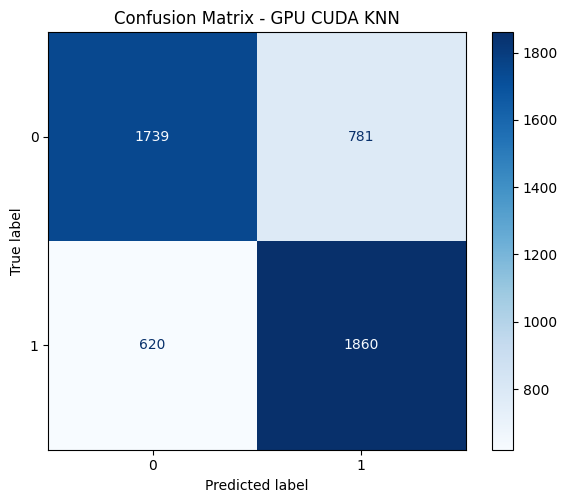

In [177]:
labels = sorted(np.unique(y_test))

fig, ax = plt.subplots(figsize=(6, 5))

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=gpu_cm,
    display_labels=labels
)

display_cm.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

ax.set_title("Confusion Matrix - GPU CUDA KNN")
plt.tight_layout()
plt.savefig("outputs/figures/confusion_matrix.png", dpi=150)
plt.show()

## Execution Time Comparison

The execution time comparison chart is saved to `outputs/figures/execution_time_comparison.png`.

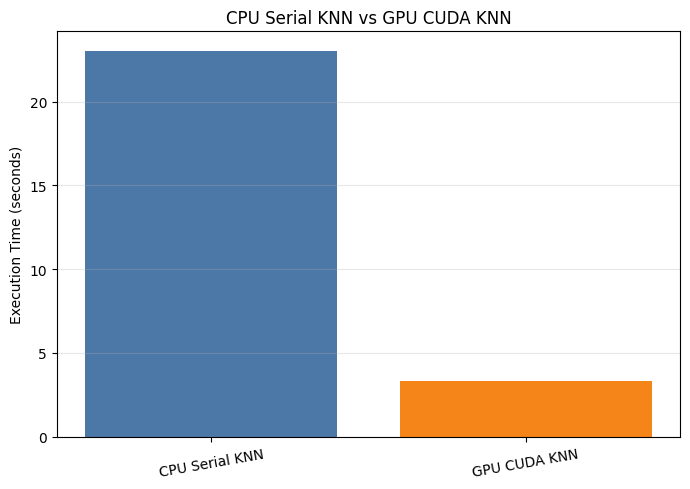

In [178]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(evaluation_results["Method"], evaluation_results["Execution Time"], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Execution Time (seconds)")
ax.set_title("CPU Serial KNN vs GPU CUDA KNN")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=10)
plt.tight_layout()
plt.savefig("outputs/figures/execution_time_comparison.png", dpi=150)
plt.show()

## Conclusion

Based on the experimental results, the implementation of the K-Nearest Neighbor (KNN) algorithm using CUDA successfully accelerated the diabetes classification process compared to the serial CPU implementation. Using 56,553 training samples, 5,000 testing samples, and 21 health indicator features, the CPU Serial KNN achieved an accuracy of 72.00% with an execution time of 23.033822 seconds. In comparison, the GPU CUDA KNN achieved an accuracy of 71.98% with an execution time of only 3.308060 seconds.

The accuracy difference between the CPU and GPU implementations was very small, approximately 0.02%, while the prediction agreement reached 99.82%. This indicates that the CUDA-based implementation maintained nearly the same classification performance as the serial version while significantly reducing computation time.

From a performance perspective, the GPU implementation achieved a speedup of approximately 6.96× compared to the CPU implementation. This improvement was made possible by parallelizing the distance computation stage of the KNN algorithm across thousands of GPU threads.

Therefore, it can be concluded that CUDA is an effective approach for accelerating computationally intensive tasks in KNN classification, particularly distance calculations. Although the classification accuracy remained around 72%, the primary objective of this study was to evaluate the benefits of parallel computing. The results demonstrate that GPU-based parallel processing can significantly improve execution performance while preserving prediction quality.